# Discovering Governing Equations with SINDy
### Applied to Sardine / Anchovy / SST dynamics, informed by SHREC and CCM

**Reference:** Brunton, S. L., Proctor, J. L., & Kutz, J. N. (2016).  
Discovering governing equations from data by sparse identification of nonlinear dynamical systems.  
*PNAS*, 113(15), 3932–3937. DOI: [10.1073/pnas.1517384113](https://doi.org/10.1073/pnas.1517384113)

---

### Background

**SINDy (Sparse Identification of Nonlinear Dynamics)** assumes that most physical and ecological
systems are governed by a small number of active terms drawn from a large candidate library.
Given a state matrix $\mathbf{X}$ (rows = time steps, columns = variables), SINDy solves:

$$\mathbf{X}(t+1) \approx \boldsymbol{\Theta}(\mathbf{X}(t))\,\boldsymbol{\Xi}$$

where $\boldsymbol{\Theta}$ is a library of candidate functions and $\boldsymbol{\Xi}$ is a
sparse coefficient matrix found by **sequential thresholded least-squares (STLS)**. A dense
$\boldsymbol{\Xi}$ signals overfitting; a sparse one suggests a true dynamical law.

We apply SINDy to four ecological time series — anchovy, sardine, SST Scripps, SST Newport —
and progressively refine the model across four stages:

| Stage | Name | Key idea |
|---|---|---|
| 1 | **Percentile SINDy** | Threshold by coefficient magnitude percentile |
| 2 | **Lambda-sweep SINDy** | Scan λ grid; keep terms stable across all λ values |
| 3 | **CCM-restricted SINDy** | Constrain libraries to CCM-confirmed causal links |
| 4 | **Non-smooth AIC SINDy** | Non-polynomial basis + AIC selection + hard sparsity cap |

In each stage the SHREC latent coordinate ψ₁ is optionally added as an exogenous driver
(the "augmented" run), letting us measure how much the hidden climate manifold improves skill.

---

### SHREC — latent driver

**SHREC** recovers a low-dimensional coordinate ψ₁ encoding the shared forcing across all
four time series. Install: `pip install git+https://github.com/williamgilpin/shrec`.
The raw eigenvector (not the smoothed trend) feeds into SINDy below.

## Imports

In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
from scipy.linalg import lstsq
from scipy.signal import sawtooth
import copy

## Data Loading and Preprocessing

Both files are z-score normalised and aligned on the same time axis.
`E_param = 3` is the SHREC embedding dimension; it determines the trim length used
when building the augmented state matrix.

Ecological data loaded: 78 annual observations (1929–2006)
ψ₁ loaded: 76 time points (1931–2006)


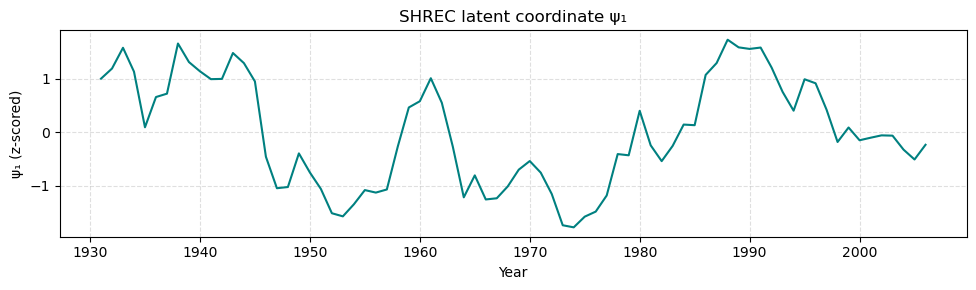

In [147]:
# ── Ecological observations ───────────────────────────────────────────────────
try:
    df_eco = pd.read_csv('sardine_anchovy_sst.csv')
    df_eco['year'] = pd.to_datetime(df_eco['year'].astype(str), format='%Y')
    df_eco = df_eco.sort_values('year').set_index('year').interpolate(method='linear')
    df_eco_normalized = (df_eco - df_eco.mean()) / df_eco.std()

    years      = df_eco.index.year.values
    sardine    = df_eco_normalized['sardine'].values
    anchovy    = df_eco_normalized['anchovy'].values
    sio_sst    = df_eco_normalized['sio_sst'].values   # SST Scripps
    np_sst     = df_eco_normalized['np_sst'].values    # SST Newport
    print(f"Ecological data loaded: {len(years)} annual observations ({years[0]}–{years[-1]})")
except FileNotFoundError:
    print("Please ensure 'sardine_anchovy_sst.csv' is in your working directory.")

# ── SHREC latent coordinate ψ₁ ────────────────────────────────────────────────
df_psi      = pd.read_csv('shrec_1var_latent_coordinates.csv')
psi_1       = df_psi['Psi_1_Standardized'].values   # already z-scored
years_shrec = df_psi['Year'].values
E_param     = 3   # embedding dimension → trim = E_param - 1 = 2
print(f"ψ₁ loaded: {len(psi_1)} time points ({years_shrec[0]}–{years_shrec[-1]})")

# ── Quick visualisation ────────────────────────────────────────────────────────
plt.figure(figsize=(10, 3))
plt.plot(years_shrec, psi_1, color='teal')
plt.xlabel('Year'); plt.ylabel('ψ₁ (z-scored)')
plt.title('SHREC latent coordinate ψ₁'); plt.grid(ls='--', alpha=0.4)
plt.tight_layout(); plt.show()

## Shared Helper Functions

All functions are defined here and used unchanged across every stage.
No function is redefined later.

| Function | Purpose |
|---|---|
| `standardise(v)` | Z-score a 1-D array |
| `poolData(X, …)` | Full polynomial + optional trig library (Stages 1–2) |
| `poolData_restricted(X, …)` | Same but restricted to named predictors (Stage 3) |
| `stls(Theta, Y, lamb)` | Sequential thresholded least-squares — handles both 1-D and 2-D targets |
| `stls_masked(Theta, y, mask)` | STLS refit on a boolean active-term mask |
| `r2_score(y_true, y_pred)` | Coefficient of determination R² |
| `r2_per_col(Y_true, Y_pred)` | R² for each column of a 2-D array |
| `build_theta_row_poly(x, …)` | Single-step feature vector for poly free-run (Stages 1–2) |
| `free_run_poly(X, …)` | Autonomous rollout using polynomial SINDy equations |
| `build_causal_library(X, …)` | Non-smooth library: |x|, relu±, triangle waves, Δclimate (Stage 4) |
| `build_feature_vector_ns(…)` | Single-step feature vector for non-smooth free-run (Stage 4) |
| `free_run_nonsmooth(results, …)` | Autonomous rollout using non-smooth SINDy equations |
| `aic_gaussian(y, y_pred, k)` | AIC criterion for Gaussian noise |
| `fit_with_aic_and_cap(…)` | λ-grid sweep with AIC + hard term cap (Stage 4) |

In [148]:
# ── Normalisation ─────────────────────────────────────────────────────────────
def standardise(v):
    return (v - np.mean(v)) / (np.std(v) + 1e-12)

# ── Full polynomial + optional trig library ───────────────────────────────────
def poolData(X, poly_order=2, var_names=None, include_trig=False):
    """Build a candidate library from all columns of X."""
    m, n = X.shape
    if var_names is None:
        var_names = [f'x{i}' for i in range(n)]
    cols, names = [np.ones(m)], ['1']
    for order in range(1, poly_order + 1):
        for combo in combinations_with_replacement(range(n), order):
            cols.append(np.prod(X[:, combo], axis=1))
            names.append(''.join(var_names[c] for c in combo))
    if include_trig:
        for i in range(n):
            cols.append(np.sin(X[:, i])); names.append(f'sin({var_names[i]})')
        for i in range(n):
            cols.append(np.cos(X[:, i])); names.append(f'cos({var_names[i]})')
    return np.column_stack(cols), names

# ── CCM-restricted library ────────────────────────────────────────────────────
def poolData_restricted(X, all_col_names, allowed_names,
                        poly_order=2, include_trig=False):
    """Build a candidate library using ONLY the allowed predictor columns."""
    m = X.shape[0]
    allowed_idx = [all_col_names.index(n) for n in allowed_names]
    X_sub = X[:, allowed_idx]
    n = len(allowed_idx)
    cols, names = [np.ones(m)], ['1']
    for order in range(1, poly_order + 1):
        for combo in combinations_with_replacement(range(n), order):
            cols.append(np.prod(X_sub[:, combo], axis=1))
            names.append(''.join(allowed_names[c] for c in combo))
    if include_trig:
        for i in range(n):
            cols.append(np.sin(X_sub[:, i])); names.append(f'sin({allowed_names[i]})')
        for i in range(n):
            cols.append(np.cos(X_sub[:, i])); names.append(f'cos({allowed_names[i]})')
    return np.column_stack(cols), names

# ── Sequential thresholded least-squares (STLS) ───────────────────────────────
def stls(Theta, Y, lamb, n_iter=10):
    """STLS for 1-D or 2-D targets. Returns Xi with same ndim as Y."""
    is_1d = (Y.ndim == 1)
    if is_1d:
        Y = Y[:, None]
    Xi, _, _, _ = lstsq(Theta, Y)
    for _ in range(n_iter):
        small = np.abs(Xi) < lamb
        Xi[small] = 0.0
        for col in range(Y.shape[1]):
            big = ~small[:, col]
            if big.sum() == 0:
                continue
            Xi[big, col], _, _, _ = lstsq(Theta[:, big], Y[:, col])
    return Xi[:, 0] if is_1d else Xi

def stls_masked(Theta, y, active_mask, n_iter=10):
    """STLS refit restricted to True entries of active_mask; returns full-length xi."""
    xi = np.zeros(Theta.shape[1])
    idx = np.where(active_mask)[0]
    if len(idx) == 0:
        return xi
    xi_sub, _, _, _ = lstsq(Theta[:, idx], y)
    for _ in range(n_iter):
        small = np.abs(xi_sub) < 1e-8 * (np.abs(xi_sub).max() + 1e-12)
        xi_sub[small] = 0.0
        big = ~small
        if big.sum() == 0:
            break
        xi_sub[big], _, _, _ = lstsq(Theta[:, idx[big]], y)
    xi[idx] = xi_sub
    return xi

# ── R² metrics ────────────────────────────────────────────────────────────────
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / (ss_tot + 1e-12)

def r2_per_col(Y_true, Y_pred):
    """R² for each column of 2-D arrays."""
    return np.array([r2_score(Y_true[:, i], Y_pred[:, i])
                     for i in range(Y_true.shape[1])])

# ── Polynomial free-run helpers (Stages 1 & 2) ────────────────────────────────
def build_theta_row_poly(x, col_names, include_trig):
    """Reconstruct one Theta row from a 1-D state vector x (polynomial library)."""
    n = len(col_names)
    row = [1.0]
    for order in range(1, 3):
        for combo in combinations_with_replacement(range(n), order):
            row.append(float(np.prod(x[list(combo)])))
    if include_trig:
        for xi in x: row.append(float(np.sin(xi)))
        for xi in x: row.append(float(np.cos(xi)))
    return np.array(row)

def free_run_poly(X_full, col_names, Xi, include_trig, n_targets=4, clip=5.0):
    """Iterate polynomial SINDy equations from X_full[0].
    Columns beyond n_targets (e.g. ψ₁) are held at their observed values."""
    T    = X_full.shape[0]
    traj = np.zeros((T, n_targets))
    traj[0] = X_full[0, :n_targets]
    for t in range(T - 1):
        x = np.array([traj[t, i] if i < n_targets else float(X_full[t, i])
                      for i in range(len(col_names))])
        theta    = build_theta_row_poly(x, col_names, include_trig)
        next_val = theta @ Xi
        traj[t+1] = np.clip(next_val[:n_targets], -clip, clip)
    return traj

# ── Non-smooth basis functions (Stage 4) ─────────────────────────────────────
def relu_pos(x): return np.maximum(0.0, x)
def relu_neg(x): return np.maximum(0.0, -x)

def tri_wave_array(t_arr, period):
    return sawtooth(2 * np.pi * t_arr / period, width=0.5)

def tri_wave_scalar(t_scalar, period):
    return float(sawtooth(2 * np.pi * t_scalar / period, width=0.5))

ECO_PERIODS = [20, 30, 50]   # ecological oscillation periods (years)

def build_causal_library(X_full, all_col_names, allowed_names, t_index):
    """Non-smooth library for Stage 4:
    intercept | linear | |x|, relu+, relu- | triangle waves | Δclimate | x·Δψ₁."""
    Xp    = X_full[:-1]
    t     = t_index[:-1].astype(float)
    a_idx = [all_col_names.index(n) for n in allowed_names]
    Xs    = Xp[:, a_idx]
    cols, names = [np.ones(len(Xp))], ['1']
    for k, nm in enumerate(allowed_names):
        cols.append(Xs[:, k]); names.append(nm)
    for k, nm in enumerate(allowed_names):
        v = Xs[:, k]
        cols.append(np.abs(v));   names.append(f'|{nm}|')
        cols.append(relu_pos(v)); names.append(f'relu+({nm})')
        cols.append(relu_neg(v)); names.append(f'relu-({nm})')
    for T_p in ECO_PERIODS:
        cols.append(tri_wave_array(t, T_p)); names.append(f'tri(t,{T_p}yr)')
    climate_vars = [nm for nm in allowed_names if nm in ('TS', 'TN', 'ψ1')]
    delta = {}
    for nm in climate_vars:
        dv = np.diff(X_full[:, all_col_names.index(nm)])
        delta[nm] = dv
        cols.append(dv); names.append(f'Δ{nm}')
    fish_vars = [nm for nm in allowed_names if nm in ('a', 's')]
    if 'ψ1' in delta and fish_vars:
        for fnm in fish_vars:
            fk = allowed_names.index(fnm)
            cols.append(Xs[:, fk] * delta['ψ1']); names.append(f'{fnm}·Δψ₁')
    return np.column_stack(cols), names

def build_feature_vector_ns(state_now, state_next_pred, allowed_names, t_scalar):
    """Single-step feature vector matching build_causal_library, for free-run rollout."""
    theta = [1.0]
    for nm in allowed_names: theta.append(state_now[nm])
    for nm in allowed_names:
        v = state_now[nm]
        theta.append(abs(v)); theta.append(relu_pos(v)); theta.append(relu_neg(v))
    for T_p in ECO_PERIODS:
        theta.append(tri_wave_scalar(t_scalar, T_p))
    climate_vars = [nm for nm in allowed_names if nm in ('TS', 'TN', 'ψ1')]
    delta = {}
    for nm in climate_vars:
        dv = state_next_pred[nm] - state_now[nm]
        delta[nm] = dv; theta.append(dv)
    fish_vars = [nm for nm in allowed_names if nm in ('a', 's')]
    if 'ψ1' in delta and fish_vars:
        for fnm in fish_vars: theta.append(state_now[fnm] * delta['ψ1'])
    return np.array(theta, dtype=float)

def free_run_nonsmooth(results, X_full, all_col_names, t_idx,
                       causal_predictors, col_map, psi1_col=None, clip_std=5.0):
    """Autonomous rollout for Stage 4 non-smooth SINDy.

    ψ₁ is always treated as exogenous (observed values used at each step).
    A two-pass scheme handles Δclimate terms:
      Pass 1 — approximate next state with Δx ≈ 0
      Pass 2 — recompute with proper Δx from the pass-1 estimate.
    """
    long_names  = list(col_map.keys())     # 'Anchovy','Sardine',... — keys in results & causal_predictors
    short_names = all_col_names[:4]         # 'a','s','TS','TN'    — keys in state dicts
    name_map    = dict(zip(long_names, short_names))   # long → short
    T    = X_full.shape[0]
    traj = np.full((T, 4), np.nan)
    traj[0] = X_full[0, :4]

    def state_dict(t):
        d = {nm: traj[t, i] for i, nm in enumerate(short_names)}
        for i, nm in enumerate(all_col_names):
            if i >= 4:          # exogenous columns (e.g. ψ1)
                d[nm] = X_full[t, i]
        return d

    for t in range(T - 1):
        s_now = state_dict(t)
        # Pass 1: preliminary next state (Δx ≈ 0)
        s_next = dict(s_now)
        if psi1_col is not None:
            s_next['ψ1'] = X_full[min(t + 1, T - 1), psi1_col]
        prelim = {}
        for i, (lnm, snm) in enumerate(zip(long_names, short_names)):
            r = results[lnm]
            theta = build_feature_vector_ns(s_now, s_next, causal_predictors[lnm], t_idx[t])
            prelim[snm] = float(np.dot(r['xi'], theta))
        s_next.update(prelim)
        # Pass 2: final prediction with corrected Δx
        for i, (lnm, snm) in enumerate(zip(long_names, short_names)):
            r = results[lnm]
            theta = build_feature_vector_ns(s_now, s_next, causal_predictors[lnm], t_idx[t])
            traj[t + 1, i] = float(np.dot(r['xi'], theta))
        traj[t + 1] = np.clip(traj[t + 1], -clip_std, clip_std)
    return traj

# ── AIC model selection (Stage 4) ─────────────────────────────────────────────
def aic_gaussian(y, y_pred, k):
    n = len(y)
    rss = np.sum((y - y_pred) ** 2) + 1e-12
    return n * np.log(rss / n) + 2 * k

def fit_with_aic_and_cap(Theta, y, lambda_grid, max_terms):
    """Sweep lambda_grid; choose λ minimising AIC with at most max_terms active terms."""
    aic_vals, xi_list, k_list = [], [], []
    for lam in lambda_grid:
        xi   = stls(Theta, y, lam)
        pred = Theta @ xi
        k    = int(np.sum(np.abs(xi) > 0))
        aic_vals.append(aic_gaussian(y, pred, k))
        xi_list.append(xi.copy()); k_list.append(k)
    aic_arr = np.array(aic_vals)
    k_arr   = np.array(k_list)
    valid   = np.where(k_arr <= max_terms)[0]
    if len(valid) == 0:
        valid = np.where(k_arr == k_arr.min())[0]
    best_i = valid[np.argmin(aic_arr[valid])]
    return xi_list[best_i], lambda_grid[best_i], aic_arr, k_arr

print('All helper functions defined successfully.')

All helper functions defined successfully.


## Shared State Matrices and Global Constants

All four stages use the same two state matrices and the same set of constants,
defined here once to avoid any inconsistency between sections.

- **Baseline** (`X_base`): 4 observed variables, z-scored, full 78-year series.
- **Augmented** (`X_aug`): same 4 variables + ψ₁, trimmed by `trim = E_param − 1 = 2` rows
  to match the SHREC coordinate length (76 time points).

Variable abbreviations used as column names throughout:
`a` = anchovy, `s` = sardine, `TS` = SST Scripps, `TN` = SST Newport, `ψ1` = SHREC latent.

In [149]:
# ── Global constants ─────────────────────────────────────────────────────────
TARGET_NAMES = ['Anchovy', 'Sardine', 'SST_SIO', 'SST_NP']
VARS         = TARGET_NAMES   # alias used in plot loops
COLORS       = ['steelblue', 'tomato', 'seagreen', 'darkorange']
col_map      = {'Anchovy': 0, 'Sardine': 1, 'SST_SIO': 2, 'SST_NP': 3}
INCLUDE_TRIG = True   # used in Stages 1–3

# ── State matrices ─────────────────────────────────────────────────────────────
trim = E_param - 1   # = 2

psi1_s = standardise(psi_1)

# Baseline: 78 time points, no ψ₁
X_base        = np.column_stack([standardise(anchovy), standardise(sardine),
                                  standardise(sio_sst), standardise(np_sst)])
cols_base     = ['a', 's', 'TS', 'TN']
all_cols_base = ['a', 's', 'TS', 'TN']

# Augmented: 76 time points (trimmed), with ψ₁
X_aug        = np.column_stack([standardise(anchovy)[trim:], standardise(sardine)[trim:],
                                 standardise(sio_sst)[trim:], standardise(np_sst)[trim:],
                                 psi1_s])
cols_aug     = ['a', 's', 'TS', 'TN', 'ψ1']
all_cols_aug = ['a', 's', 'TS', 'TN', 'ψ1']

# Year axes aligned to each matrix
t_base = years[1:]          # OSA targets for baseline  (years 1932–2008 if N=78)
t_aug  = years[trim + 1:]   # OSA targets for augmented (2 years shorter)
t_yrs  = years[trim:]       # full time axis for augmented state matrix
t_idx      = np.arange(len(t_yrs))   # integer index for augmented data (triangle-wave features)
t_idx_base = np.arange(len(years))   # integer index for baseline data (same length as years)

print(f'Baseline  state matrix : {X_base.shape}  ({years[0]}–{years[-1]})')
print(f'Augmented state matrix : {X_aug.shape}  ({t_yrs[0]}–{t_yrs[-1]})')

Baseline  state matrix : (78, 4)  (1929–2006)
Augmented state matrix : (76, 5)  (1931–2006)


---
## Stage 1 — Percentile-Based SINDy

The full polynomial + trigonometric library is built from all four observed variables
(and ψ₁ in the augmented run). Terms are retained if their unconstrained OLS coefficient
magnitude exceeds the `TOP_PCT`-th percentile of all coefficients, then refit by STLS.

This stage makes **no assumptions about causal structure** — it is purely data-driven.
The main risk is overfitting: trig + poly-2 terms can fit noise, so the free-running
simulation (below) immediately reveals whether the equations generalise.


══════════════════════════════════════════════════════════════
  BASELINE  —  Discovered equations  (top_pct=40%)
══════════════════════════════════════════════════════════════
  Anchovy(t+1) = -0.4413·a +0.6024·sin(a)
  Sardine(t+1) = -0.4967·1 -0.4947·as +0.6531·cos(s)
  SST_SIO(t+1) = +0.8931·TS
  SST_NP(t+1) = +0.8050·TN

  R²: Anchovy: 0.157   Sardine: 0.134   SST_SIO: 0.757   SST_NP: 0.646

══════════════════════════════════════════════════════════════
  AUGMENTED  —  Discovered equations  (top_pct=30%)
══════════════════════════════════════════════════════════════
  Anchovy(t+1) = 0
  Sardine(t+1) = -4.7551·1 +0.6795·ψ1 +2.0752·ψ1ψ1 -0.8476·sin(ψ1) +4.7135·cos(ψ1)
  SST_SIO(t+1) = +0.8946·TS
  SST_NP(t+1) = +3.6291·1 -1.5740·ψ1ψ1 -3.6443·cos(ψ1)
  ψ1(t+1) = +0.8899·ψ1

  R²: Anchovy: -0.000   Sardine: 0.061   SST_SIO: 0.769   SST_NP: 0.022   ψ1: 0.802


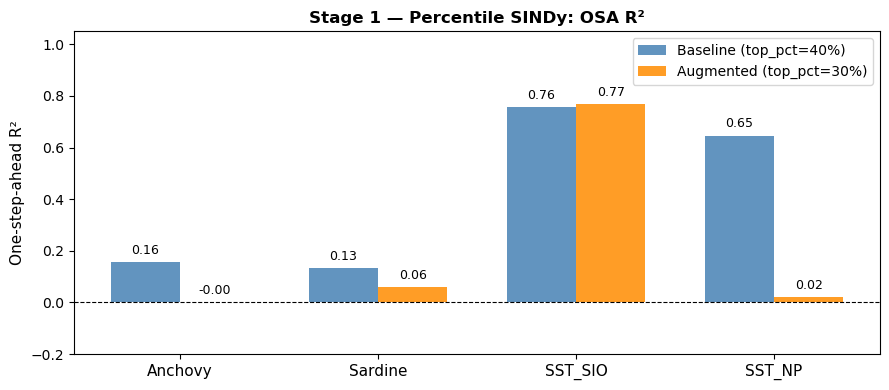

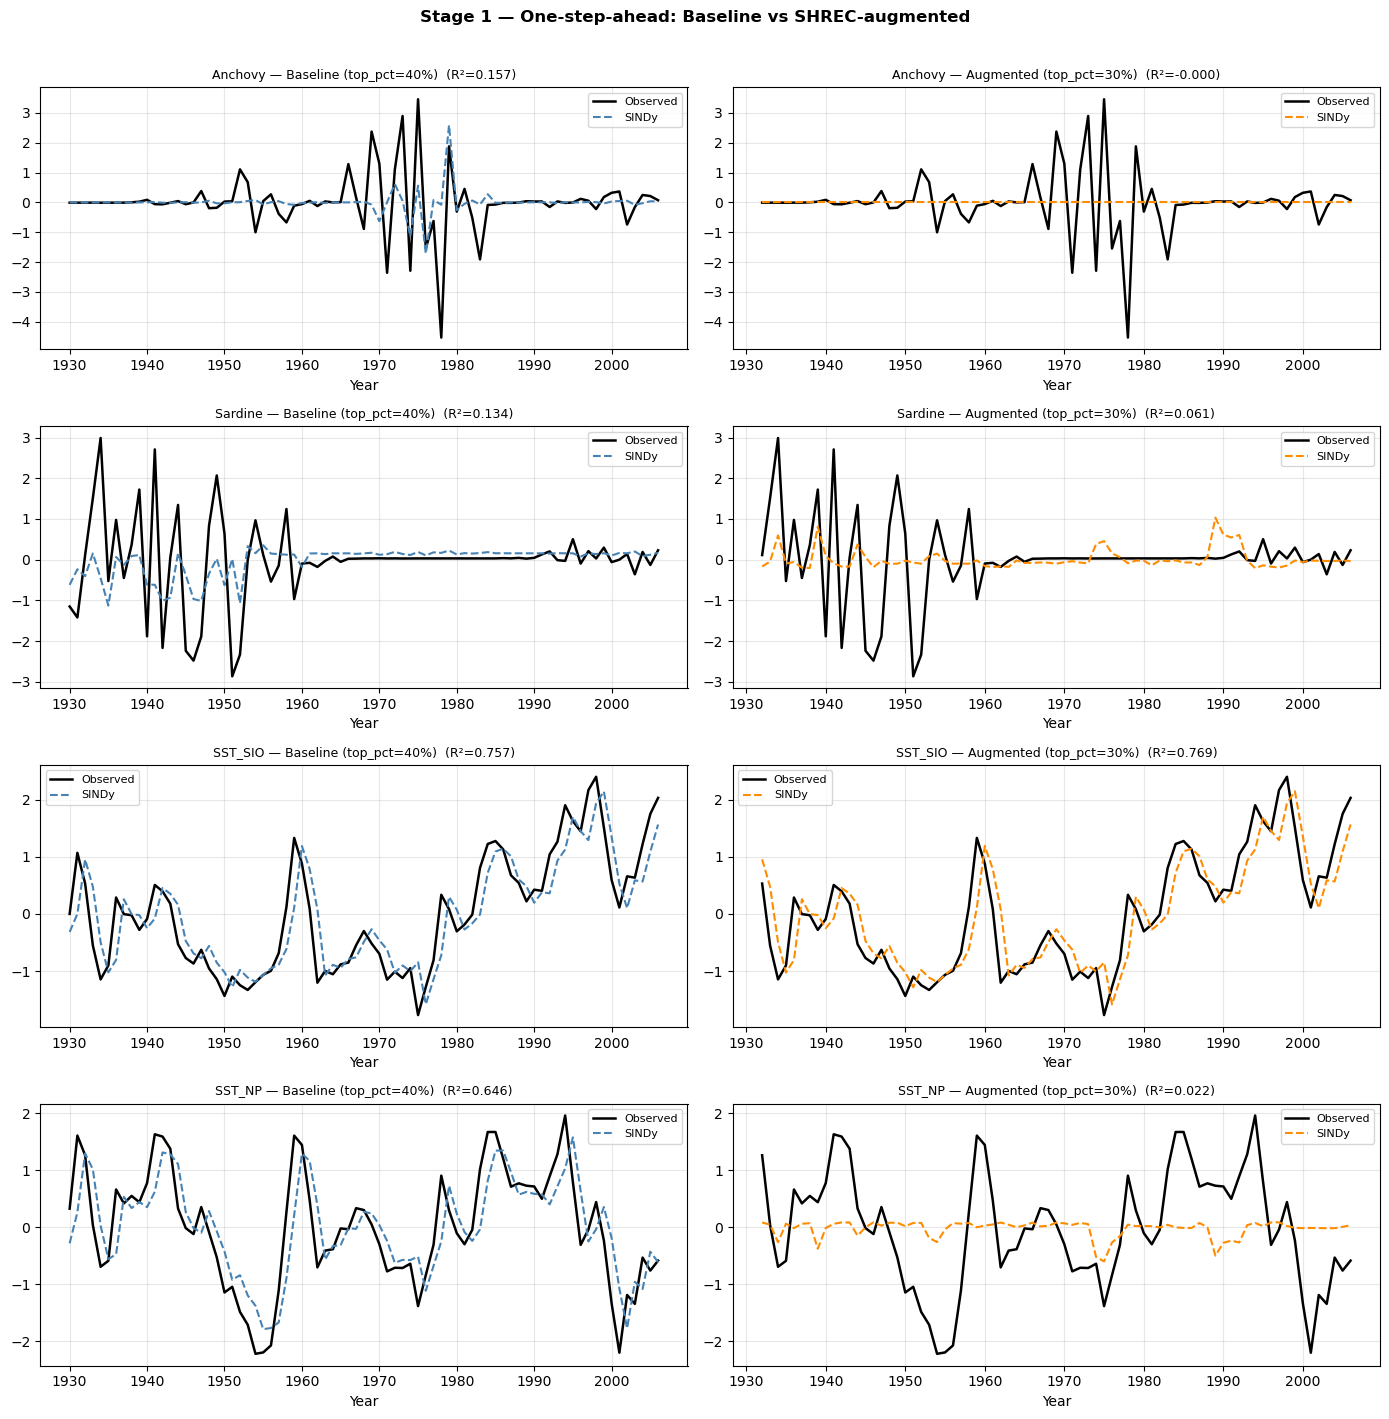

In [150]:
TOP_PCT_BASE = 40   # keep top 40 % of terms in the baseline run
TOP_PCT_AUG  = 30   # slightly sparser for augmented (more features)

def sparsify_pct(Theta, Y, top_pct, n_iter=10):
    """Multi-target percentile STLS. Returns (Xi, lambda, Xi_unconstrained)."""
    Xi0, _, _, _ = lstsq(Theta, Y)
    lamb = float(np.percentile(np.abs(Xi0).flatten(), 100 - top_pct))
    Xi = stls(Theta, Y, lamb, n_iter=n_iter)
    return Xi, lamb, Xi0

def run_stage1(X, col_names, long_names, top_pct, label):
    """Fit percentile SINDy. Returns (Xi, lambda, features, predictions, targets, R²)."""
    Xt   = X[:-1]
    Xtp1 = X[1:]
    Theta, feat = poolData(Xt, poly_order=2, var_names=col_names, include_trig=INCLUDE_TRIG)
    Xi0, _, _, _ = lstsq(Theta, Xtp1)
    Xi, lamb, _ = sparsify_pct(Theta, Xtp1, top_pct)
    pred   = Theta @ Xi
    r2_vals = [r2_score(Xtp1[:, i], pred[:, i]) for i in range(len(long_names))]
    print(f"\n{'═'*62}")
    print(f"  {label}  —  Discovered equations  (top_pct={top_pct}%)")
    print(f"{'═'*62}")
    for i, name in enumerate(long_names):
        terms = [f'{Xi[j,i]:+.4f}·{feat[j]}' for j in range(len(feat)) if abs(Xi[j, i]) > 1e-8]
        print(f"  {name}(t+1) = {' '.join(terms) if terms else '0'}")
    print(f"\n  R²: " + '   '.join(f"{long_names[i]}: {r2_vals[i]:.3f}" for i in range(len(long_names))))
    return Xi, lamb, feat, pred, Xtp1, r2_vals

# ── Run ───────────────────────────────────────────────────────────────────────
obs_long = ['Anchovy', 'Sardine', 'SST_SIO', 'SST_NP']
aug_long = obs_long + ['ψ1']

Xi_base_s1, lamb_base_s1, feat_base_s1, pred_base_s1, Xtp1_base_s1, r2_base_s1 = run_stage1(
    X_base, cols_base, obs_long, TOP_PCT_BASE, 'BASELINE')

Xi_aug_s1, lamb_aug_s1, feat_aug_s1, pred_aug_s1, Xtp1_aug_s1, r2_aug_s1 = run_stage1(
    X_aug, cols_aug, aug_long, TOP_PCT_AUG, 'AUGMENTED')

# ── R² bar chart ──────────────────────────────────────────────────────────────
x = np.arange(4); width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, r2_base_s1, width, label=f'Baseline (top_pct={TOP_PCT_BASE}%)',
            color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, r2_aug_s1[:4], width, label=f'Augmented (top_pct={TOP_PCT_AUG}%)',
            color='darkorange', alpha=0.85)
for bars, vals in [(b1, r2_base_s1), (b2, r2_aug_s1[:4])]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(obs_long, fontsize=11)
ax.set_ylabel('One-step-ahead R²', fontsize=11)
ax.set_title('Stage 1 — Percentile SINDy: OSA R²', fontsize=12, fontweight='bold')
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.legend(fontsize=10); ax.set_ylim(-0.2, 1.05)
plt.tight_layout(); plt.show()

# ── OSA trajectory plots ──────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
for i, (vname, c) in enumerate(zip(obs_long, COLORS)):
    for j, (pred, Xtp1, lab, col, t_ax) in enumerate([
        (pred_base_s1, Xtp1_base_s1, f'Baseline (top_pct={TOP_PCT_BASE}%)', 'steelblue', t_base),
        (pred_aug_s1,  Xtp1_aug_s1,  f'Augmented (top_pct={TOP_PCT_AUG}%)', 'darkorange', t_aug),
    ]):
        ax = axes[i, j]
        r2v = r2_base_s1[i] if j == 0 else r2_aug_s1[i]
        ax.plot(t_ax, Xtp1[:, i], color='k', lw=1.8, label='Observed')
        ax.plot(t_ax, pred[:, i], color=col, lw=1.5, ls='--', label='SINDy')
        ax.set_title(f'{vname} — {lab}  (R²={r2v:.3f})', fontsize=9)
        ax.set_xlabel('Year'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Stage 1 — One-step-ahead: Baseline vs SHREC-augmented',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

### Stage 1 — Free-Running Simulation

One-step-ahead (OSA) prediction re-anchors to observed data at every step, so errors never
compound. **Free-running** starts from $\mathbf{x}(t_0)$ and iterates autonomously —
a much harder test. A large drop from OSA to free-run R² signals overfitting.

Stage 1 — OSA vs Free-Run R²
  Variable        OSA base    FR base     OSA +ψ₁     FR +ψ₁
  Anchovy            0.157      0.000      -0.000      0.000
  Sardine            0.134      0.034       0.061      0.087
  SST_SIO            0.757      0.007       0.769     -0.120
  SST_NP             0.646     -0.021       0.022      0.055


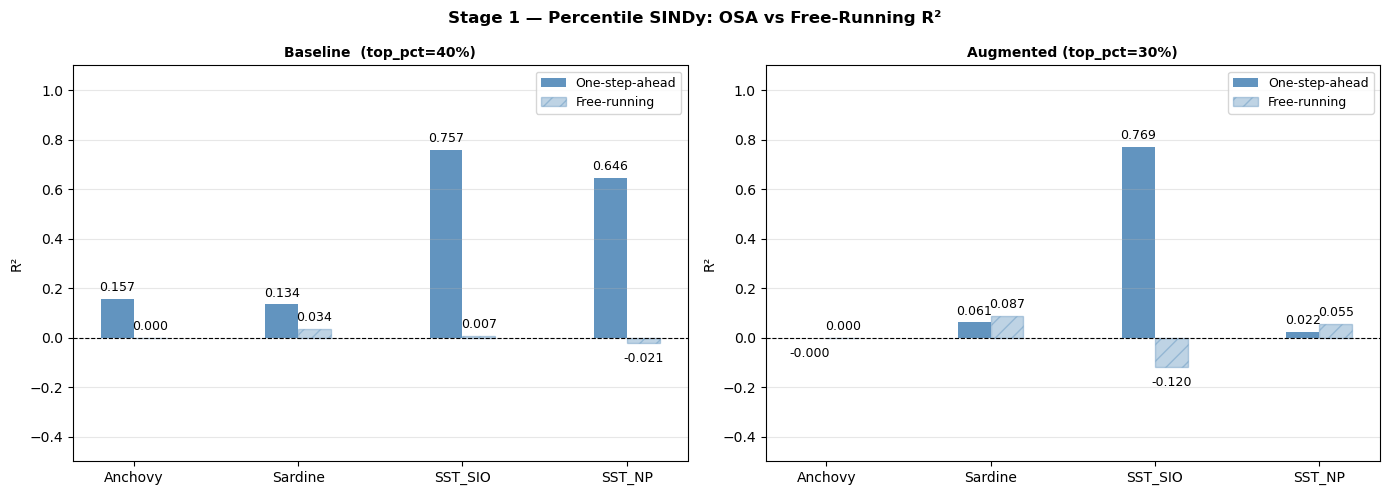

In [151]:
# ── Free-run ──────────────────────────────────────────────────────────────────
traj_base_s1 = free_run_poly(X_base, cols_base, Xi_base_s1, INCLUDE_TRIG)
traj_aug_s1  = free_run_poly(X_aug,  cols_aug,  Xi_aug_s1,  INCLUDE_TRIG)

r2_fr_base_s1 = [r2_score(X_base[:, i], traj_base_s1[:, i]) for i in range(4)]
r2_fr_aug_s1  = [r2_score(X_aug[:,  i], traj_aug_s1[:,  i]) for i in range(4)]

print('Stage 1 — OSA vs Free-Run R²')
print(f"  {'Variable':12s}  {'OSA base':>10}  {'FR base':>9}  {'OSA +ψ₁':>10}  {'FR +ψ₁':>9}")
for i, v in enumerate(obs_long):
    print(f"  {v:12s}  {r2_base_s1[i]:>10.3f}  {r2_fr_base_s1[i]:>9.3f}"
          f"  {r2_aug_s1[i]:>10.3f}  {r2_fr_aug_s1[i]:>9.3f}")

# ── Free-run bar chart ────────────────────────────────────────────────────────
x, w = np.arange(4), 0.2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, r2_osa, r2_fr in [
    (axes[0], f'Baseline  (top_pct={TOP_PCT_BASE}%)', r2_base_s1,    r2_fr_base_s1),
    (axes[1], f'Augmented (top_pct={TOP_PCT_AUG}%)',  r2_aug_s1[:4], r2_fr_aug_s1),
]:
    b1 = ax.bar(x - w/2, r2_osa, w, color='steelblue', alpha=0.85, label='One-step-ahead')
    b2 = ax.bar(x + w/2, r2_fr,  w, color='steelblue', alpha=0.35,
                hatch='//', edgecolor='steelblue', label='Free-running')
    for bar, v in list(zip(b1, r2_osa)) + list(zip(b2, r2_fr)):
        yoff = 0.02 if v >= 0 else -0.09
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + yoff,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xticks(x); ax.set_xticklabels(VARS, fontsize=10)
    ax.set_ylabel('R²'); ax.set_ylim(-0.5, 1.1)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Stage 1 — Percentile SINDy: OSA vs Free-Running R²',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Stage 2 — Lambda-Sweep SINDy with Variance-Based Term Selection

Instead of a fixed percentile, we scan `top_pct` from 10 % to 90 % in steps of 10.
For each λ, STLS produces a coefficient matrix. A term is **stable** if its variance
across all λ runs is below `VAR_THRESHOLD` and its mean magnitude exceeds a negligibility
floor. The stable subset is then refit by unconstrained OLS.

This protects against terms that only survive at one specific λ (likely artefacts).


══════════════════════════════════════════════════════════════════════
  BASELINE  |  VAR_THRESHOLD=0.002
══════════════════════════════════════════════════════════════════════
   top_pct         λ   active  R²(Anc)  R²(Sar)  R²(SST)  R²(SST)
  ─────────────────────────────────────────────────────────────────
        10%    1.1629        0    -0.000    -0.001    -0.000    -0.000
        20%    0.7261        1    -0.000    -0.001     0.757    -0.000
        30%    0.5626        2    -0.000    -0.001     0.757     0.646
        40%    0.4201        7     0.157     0.134     0.757     0.646
        50%    0.2886       29     0.157     0.343     0.765     0.697
        60%    0.1985       33     0.157     0.343     0.792     0.715
        70%    0.1172       55     0.223     0.343     0.816     0.731
        80%    0.0800       68     0.230     0.354     0.826     0.746
        90%    0.0374       82     0.248     0.359     0.826     0.759

  Terms surviving VAR_THRESHOLD=0.002:
    Ancho

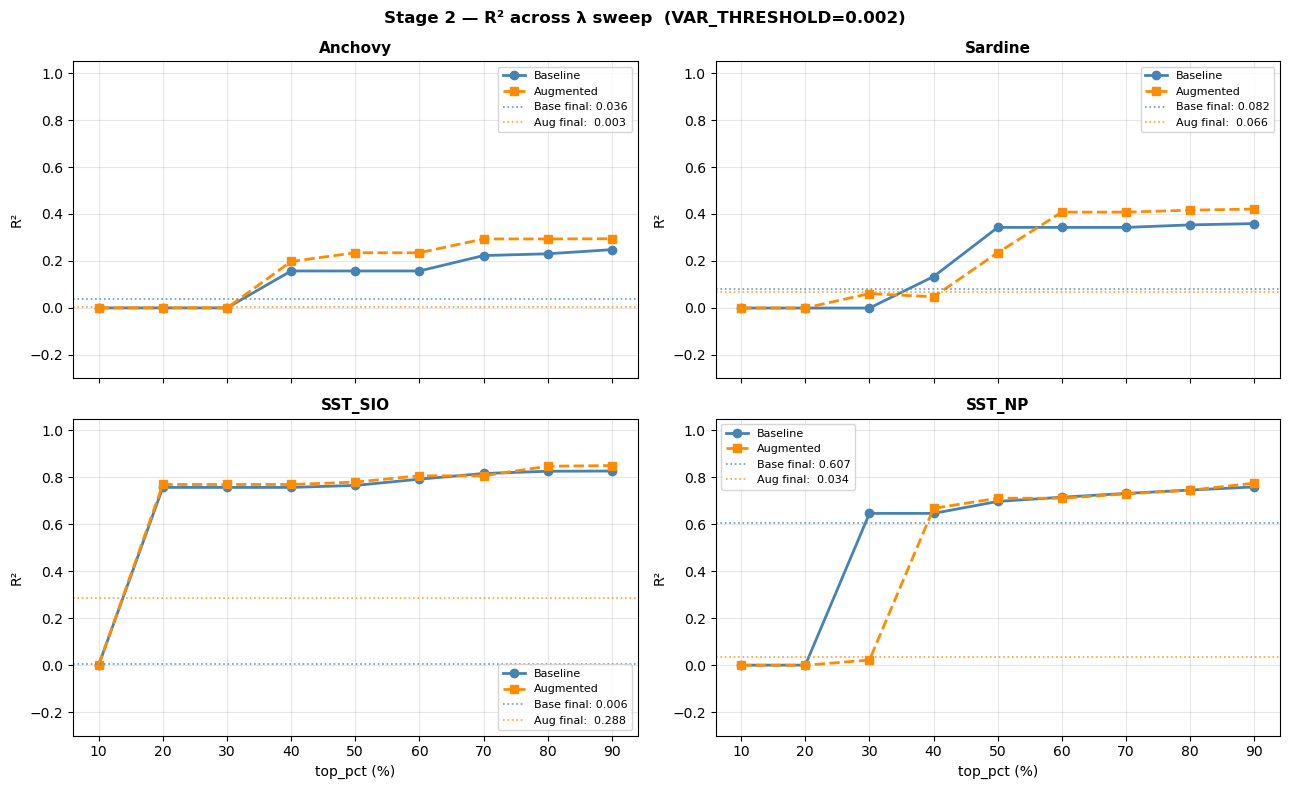

In [152]:
TOP_PCT_STEPS = list(range(10, 100, 10))
VAR_THRESHOLD = 0.002   # raise if all equations come out empty
N_ITER        = 10

def run_stage2_lambda_sweep(X_full, pred_col_names, label):
    """Full-library lambda sweep with variance-based term selection."""
    Xt   = X_full[:-1]
    Xtp1 = X_full[1:, :4]
    Theta, feat = poolData(Xt, poly_order=2, var_names=pred_col_names, include_trig=INCLUDE_TRIG)
    n_feat, n_target = len(feat), 4

    Xi0, _, _, _ = lstsq(Theta, Xtp1)
    all_Xi   = np.zeros((len(TOP_PCT_STEPS), n_feat, n_target))
    all_r2   = np.zeros((len(TOP_PCT_STEPS), n_target))
    all_lamb = []

    print(f"\n{'═'*70}")
    print(f"  {label}  |  VAR_THRESHOLD={VAR_THRESHOLD}")
    print(f"{'═'*70}")
    print(f"  {'top_pct':>8}  {'λ':>8}  {'active':>7}  " +
          '  '.join(f'R²({n[:3]})' for n in TARGET_NAMES))
    print(f"  {'─'*65}")
    for k, top_pct in enumerate(TOP_PCT_STEPS):
        lamb = float(np.percentile(np.abs(Xi0).flatten(), 100 - top_pct))
        all_lamb.append(lamb)
        Xi       = stls(Theta, Xtp1, lamb, n_iter=N_ITER)
        all_Xi[k]= Xi
        r2v      = r2_per_col(Xtp1, Theta @ Xi)
        all_r2[k]= r2v
        n_active = int(np.sum(np.abs(Xi) > 1e-10))
        print(f"  {top_pct:>8}%  {lamb:>8.4f}  {n_active:>7}  " +
              '  '.join(f'{v:8.3f}' for v in r2v))

    coef_mean   = np.mean(all_Xi, axis=0)
    coef_var    = np.var( all_Xi, axis=0)
    stable_mask = (coef_var < VAR_THRESHOLD) & (np.abs(coef_mean) > 1e-6)

    print(f"\n  Terms surviving VAR_THRESHOLD={VAR_THRESHOLD}:")
    for col, tname in enumerate(TARGET_NAMES):
        idx = np.where(stable_mask[:, col])[0]
        print(f"    {tname}: {len(idx)} terms  " +
              (f"→ {[feat[i] for i in idx]}" if len(idx) else "⚠ none — raise VAR_THRESHOLD"))

    Xi_final = np.zeros((n_feat, n_target))
    for col in range(n_target):
        idx = np.where(stable_mask[:, col])[0]
        if len(idx) == 0: continue
        idx = idx[np.argsort(coef_var[idx, col])]
        xi_col, _, _, _ = lstsq(Theta[:, idx], Xtp1[:, col])
        Xi_final[idx, col] = xi_col

    pred_final = Theta @ Xi_final
    r2_final   = r2_per_col(Xtp1, pred_final)
    return (Theta, feat, Xi_final, pred_final, Xtp1,
            r2_final, all_Xi, all_r2, all_lamb, coef_mean, coef_var, stable_mask)

# ── Run ───────────────────────────────────────────────────────────────────────
(Th_b, feat_b, Xi_b, pred_b, Ytp1_b,
 r2_b, allXi_b, allR2_b, lambs_b, mean_b, var_b, mask_b) = run_stage2_lambda_sweep(
    X_base, cols_base, 'BASELINE')

(Th_a, feat_a, Xi_a, pred_a, Ytp1_a,
 r2_a, allXi_a, allR2_a, lambs_a, mean_a, var_a, mask_a) = run_stage2_lambda_sweep(
    X_aug, cols_aug, 'AUGMENTED')

# ── Final equations ───────────────────────────────────────────────────────────
for label, Xi, feat in [('BASELINE', Xi_b, feat_b), ('AUGMENTED', Xi_a, feat_a)]:
    print(f"\n{'═'*70}")
    print(f"  {label}  —  Final equations  (variance-selected + refit)")
    print(f"{'═'*70}")
    for i, tname in enumerate(TARGET_NAMES):
        terms = [f'{Xi[j,i]:+.4f}·{feat[j]}' for j in range(len(feat)) if abs(Xi[j, i]) > 1e-10]
        print(f"  {tname}(t+1) = {' '.join(terms) if terms else '0'}")

# ── R² across lambda sweep ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
for ax, i, tname in zip(axes.flat, range(4), TARGET_NAMES):
    ax.plot(TOP_PCT_STEPS, allR2_b[:, i], 'o-',  color='steelblue', lw=2, label='Baseline')
    ax.plot(TOP_PCT_STEPS, allR2_a[:, i], 's--', color='darkorange', lw=2, label='Augmented')
    ax.axhline(r2_b[i], color='steelblue',  lw=1.2, ls=':', alpha=0.8, label=f'Base final: {r2_b[i]:.3f}')
    ax.axhline(r2_a[i], color='darkorange', lw=1.2, ls=':', alpha=0.8, label=f'Aug final:  {r2_a[i]:.3f}')
    ax.set_title(tname, fontsize=11, fontweight='bold')
    ax.set_ylabel('R²'); ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_ylim(-0.3, 1.05)
axes[1, 0].set_xlabel('top_pct (%)'); axes[1, 1].set_xlabel('top_pct (%)')
fig.suptitle(f'Stage 2 — R² across λ sweep  (VAR_THRESHOLD={VAR_THRESHOLD})',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

In [153]:
# ── Free-run — Stage 2 ───────────────────────────────────────────────────────
traj_base_s2 = free_run_poly(X_base, cols_base, Xi_b, INCLUDE_TRIG)
traj_aug_s2  = free_run_poly(X_aug,  cols_aug,  Xi_a, INCLUDE_TRIG)

r2_fr_base_s2 = [r2_score(X_base[:, i], traj_base_s2[:, i]) for i in range(4)]
r2_fr_aug_s2  = [r2_score(X_aug[:,  i], traj_aug_s2[:,  i]) for i in range(4)]

print('Stage 2 — OSA vs Free-Run R²')
print(f"  {'Variable':12s}  {'OSA base':>10}  {'FR base':>9}  {'OSA +ψ₁':>10}  {'FR +ψ₁':>9}")
for i, v in enumerate(TARGET_NAMES):
    print(f"  {v:12s}  {r2_b[i]:>10.3f}  {r2_fr_base_s2[i]:>9.3f}"
          f"  {r2_a[i]:>10.3f}  {r2_fr_aug_s2[i]:>9.3f}")

Stage 2 — OSA vs Free-Run R²
  Variable        OSA base    FR base     OSA +ψ₁     FR +ψ₁
  Anchovy            0.036     -0.014       0.003     -0.001
  Sardine            0.082      0.042       0.066      0.023
  SST_SIO            0.006      0.002       0.288     -0.093
  SST_NP             0.607     -0.847       0.034      0.040


---
## Stage 3 — CCM-Restricted SINDy

Stages 1–2 let each species appear as a predictor in every equation, which can produce
spurious reverse-causal links (e.g. fish predicting SST). CCM analysis established
the true causal graph:

```
SST Scripps (TS) ──→ Sardine
SST Newport  (TN) ──→ Anchovy
No direct Sardine ↔ Anchovy interaction
```

We now hard-wire this graph by specifying `ALLOWED_PREDICTORS` per equation.
Two term-selection strategies are compared within this causal scaffold.

### 3a — Percentile-based selection (per equation)


══════════════════════════════════════════════════════════════════════
  BASELINE (percentile)  |  COEFF_PERCENTILE=75%
══════════════════════════════════════════════════════════════════════
  Anchovy(t+1)  R²=0.010  predictors: ['a', 'TS', 'TN']
  Sardine(t+1)  R²=0.006  predictors: ['s', 'TS', 'TN']
  SST_SIO(t+1)  R²=0.758  predictors: ['a', 'TS', 'TN']
  SST_NP(t+1)  R²=0.058  predictors: ['TS', 'TN']

══════════════════════════════════════════════════════════════════════
  AUGMENTED (percentile)  |  COEFF_PERCENTILE=75%
══════════════════════════════════════════════════════════════════════
  Anchovy(t+1)  R²=0.010  predictors: ['a', 'TS', 'TN', 'ψ1']
  Sardine(t+1)  R²=0.072  predictors: ['s', 'TS', 'TN', 'ψ1']
  SST_SIO(t+1)  R²=0.779  predictors: ['a', 'TS', 'TN', 'ψ1']
  SST_NP(t+1)  R²=0.677  predictors: ['TS', 'TN', 'ψ1']

══════════════════════════════════════════════════════════════════════
  BASELINE  —  Final equations
════════════════════════════════════════════════════

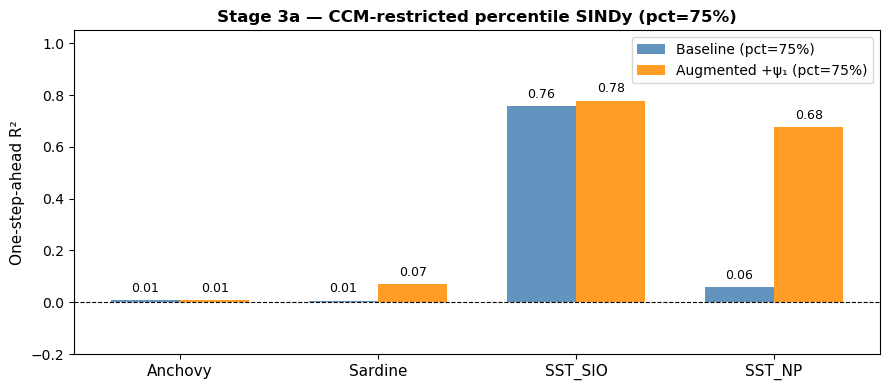

Stage 3a — OSA vs Free-Run R²
  Variable        OSA base    FR base     OSA +ψ₁     FR +ψ₁
  Anchovy            0.010     -0.000       0.010      0.001
  Sardine            0.006      0.037       0.072      0.075
  SST_SIO            0.758     -0.103       0.779     -0.421
  SST_NP             0.058     -0.062       0.677     -0.167


In [154]:
COEFF_PERCENTILE = 75   # raise → sparser; lower → denser
N_ITER_S3        = 10

ALLOWED_PREDICTORS_S3 = {
    'Anchovy' : ['a', 'TS', 'TN'],
    'Sardine' : ['s', 'TS', 'TN'],
    'SST_SIO' : ['a', 'TS', 'TN'],
    'SST_NP'  : ['TS', 'TN'],
}
ALLOWED_PREDICTORS_S3_AUG = copy.deepcopy(ALLOWED_PREDICTORS_S3)
for key in ALLOWED_PREDICTORS_S3_AUG:
    ALLOWED_PREDICTORS_S3_AUG[key].append('ψ1')

def run_pct_restricted(X_full, all_col_names, allowed_predictors, coeff_pct, label):
    """Per-equation percentile SINDy with CCM-restricted predictor sets."""
    Xt   = X_full[:-1]
    Xtp1 = X_full[1:, :4]
    print(f"\n{'═'*70}")
    print(f"  {label}  |  COEFF_PERCENTILE={coeff_pct}%")
    print(f"{'═'*70}")
    results = {}
    for t_i, tname in enumerate(TARGET_NAMES):
        y       = Xtp1[:, t_i]
        allowed = allowed_predictors[tname]
        Theta, feat = poolData_restricted(Xt, all_col_names, allowed,
                                          poly_order=2, include_trig=INCLUDE_TRIG)
        xi0, _, _, _ = lstsq(Theta, y)
        threshold = np.percentile(np.abs(xi0), coeff_pct)
        active    = np.abs(xi0) >= threshold
        xi_final  = stls_masked(Theta, y, active, n_iter=N_ITER_S3)
        pred_final = Theta @ xi_final
        r2_final   = r2_score(y, pred_final)
        print(f"  {tname}(t+1)  R²={r2_final:.3f}  predictors: {allowed}")
        results[tname] = dict(feat=feat, Theta=Theta, y=y, xi0=xi0,
                               threshold=threshold, active=active,
                               xi_final=xi_final, pred_final=pred_final,
                               r2_final=r2_final, allowed=allowed)
    return results

res_pct_b = run_pct_restricted(X_base, cols_base, ALLOWED_PREDICTORS_S3,
                                 COEFF_PERCENTILE, 'BASELINE (percentile)')
res_pct_a = run_pct_restricted(X_aug,  cols_aug,  ALLOWED_PREDICTORS_S3_AUG,
                                 COEFF_PERCENTILE, 'AUGMENTED (percentile)')

# ── Equations and R² chart ────────────────────────────────────────────────────
for label, res in [('BASELINE', res_pct_b), ('AUGMENTED', res_pct_a)]:
    print(f"\n{'═'*70}")
    print(f"  {label}  —  Final equations")
    print(f"{'═'*70}")
    for tname in TARGET_NAMES:
        r = res[tname]; xi = r['xi_final']; feat = r['feat']
        terms = [f"{xi[j]:+.4f}·{feat[j]}" for j in range(len(feat)) if abs(xi[j]) > 1e-10]
        print(f"  {tname}(t+1) = {' '.join(terms) if terms else '0'}")
        print(f"    R²={r['r2_final']:.3f}  |  predictors: {r['allowed']}")

x = np.arange(4); width = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x - width/2, [res_pct_b[n]['r2_final'] for n in TARGET_NAMES], width,
            label=f'Baseline (pct={COEFF_PERCENTILE}%)', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, [res_pct_a[n]['r2_final'] for n in TARGET_NAMES], width,
            label=f'Augmented +ψ₁ (pct={COEFF_PERCENTILE}%)', color='darkorange', alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(TARGET_NAMES, fontsize=11)
ax.set_ylabel('One-step-ahead R²', fontsize=11)
ax.set_title(f'Stage 3a — CCM-restricted percentile SINDy (pct={COEFF_PERCENTILE}%)',
             fontsize=12, fontweight='bold')
ax.axhline(0, color='k', lw=0.8, ls='--'); ax.legend(fontsize=10); ax.set_ylim(-0.2, 1.05)
plt.tight_layout(); plt.show()

# ── Free-run — Stage 3a ───────────────────────────────────────────────────────
# Uses free_run_poly with restricted predictors encoded in the stored xi_final.
# We rebuild each equation's theta row using the same poolData_restricted logic
# via build_theta_row_poly on the appropriate sub-vector.

def free_run_restricted_pct(res_dict, X_full, all_col_names, n_targets=4, clip=5.0):
    """Free-run for CCM-restricted percentile SINDy (Stage 3a)."""
    T      = X_full.shape[0]
    traj   = np.zeros((T, n_targets))
    traj[0] = X_full[0, :n_targets]
    targ_i  = {nm: i for i, nm in enumerate(TARGET_NAMES)}
    for t in range(T - 1):
        state = {c: (traj[t, i] if i < n_targets else float(X_full[t, i]))
                 for i, c in enumerate(all_col_names)}
        for tname in TARGET_NAMES:
            allowed = res_dict[tname]['allowed']
            xi      = res_dict[tname]['xi_final']
            x_vec   = np.array([state[n] for n in allowed])
            # match poolData_restricted: intercept + poly-2 + trig (if INCLUDE_TRIG)
            row = build_theta_row_poly(x_vec, allowed, INCLUDE_TRIG)
            if len(row) != len(xi):
                row = build_theta_row_poly(x_vec, allowed, False)
            traj[t+1, targ_i[tname]] = np.clip(float(np.dot(row, xi)), -clip, clip)
    return traj

traj_pct_base = free_run_restricted_pct(res_pct_b, X_base, cols_base)
traj_pct_aug  = free_run_restricted_pct(res_pct_a, X_aug,  cols_aug)

r2_fr_pct_base = [r2_score(X_base[:, i], traj_pct_base[:, i]) for i in range(4)]
r2_fr_pct_aug  = [r2_score(X_aug[:,  i], traj_pct_aug[:,  i]) for i in range(4)]

print('Stage 3a — OSA vs Free-Run R²')
print(f"  {'Variable':12s}  {'OSA base':>10}  {'FR base':>9}  {'OSA +ψ₁':>10}  {'FR +ψ₁':>9}")
for i, v in enumerate(TARGET_NAMES):
    print(f"  {v:12s}  {res_pct_b[v]['r2_final']:>10.3f}  {r2_fr_pct_base[i]:>9.3f}"
          f"  {res_pct_a[v]['r2_final']:>10.3f}  {r2_fr_pct_aug[i]:>9.3f}")

### 3b — Variance-based selection (per equation)

In [155]:
VAR_THRESHOLD_S3 = 0.01

ALLOWED_PREDICTORS_S3_VAR = {
    'Anchovy' : ['a',  'TN'],
    'Sardine' : ['s',  'TS'],
    'SST_SIO' : ['TS', 'TN'],
    'SST_NP'  : ['TS', 'TN'],
}
ALLOWED_PREDICTORS_S3_VAR_AUG = copy.deepcopy(ALLOWED_PREDICTORS_S3_VAR)
for key in ALLOWED_PREDICTORS_S3_VAR_AUG:
    ALLOWED_PREDICTORS_S3_VAR_AUG[key].append('ψ1')

def run_var_restricted(X_full, all_col_names, label, allowed_predictors):
    """Per-equation variance-based SINDy with CCM-restricted predictor sets."""
    Xt   = X_full[:-1]
    Xtp1 = X_full[1:, :4]
    print(f"\n{'═'*70}")
    print(f"  {label}  |  VAR_THRESHOLD={VAR_THRESHOLD_S3}")
    print(f"{'═'*70}")
    results = {}
    for t_i, tname in enumerate(TARGET_NAMES):
        y       = Xtp1[:, t_i]
        allowed = allowed_predictors[tname]
        Theta, feat = poolData_restricted(Xt, all_col_names, allowed,
                                          poly_order=2, include_trig=INCLUDE_TRIG)
        xi0, _, _, _ = lstsq(Theta, y)
        all_xi = np.zeros((len(TOP_PCT_STEPS), len(feat)))
        for k, top_pct in enumerate(TOP_PCT_STEPS):
            lamb = float(np.percentile(np.abs(xi0), 100 - top_pct))
            all_xi[k] = stls(Theta, y, lamb, n_iter=N_ITER)
        coef_mean = np.mean(all_xi, axis=0)
        coef_var  = np.var( all_xi, axis=0)
        stable_idx = np.where((coef_var < VAR_THRESHOLD_S3) & (np.abs(coef_mean) > 1e-6))[0]
        stable_idx = stable_idx[np.argsort(coef_var[stable_idx])]
        xi_final = np.zeros(len(feat))
        if len(stable_idx) > 0:
            xi_col, _, _, _ = lstsq(Theta[:, stable_idx], y)
            xi_final[stable_idx] = xi_col
        pred_final = Theta @ xi_final
        r2_final   = r2_score(y, pred_final)
        print(f"  {tname}  R²={r2_final:.3f}  stable: {[feat[i] for i in stable_idx]}")
        results[tname] = dict(feat=feat, Theta=Theta, y=y, xi_final=xi_final,
                               pred_final=pred_final, r2_final=r2_final,
                               stable_idx=stable_idx, coef_mean=coef_mean, coef_var=coef_var,
                               allowed=allowed)
    return results

res_var_b = run_var_restricted(X_base, cols_base, 'BASELINE',  ALLOWED_PREDICTORS_S3_VAR)
res_var_a = run_var_restricted(X_aug,  cols_aug,  'AUGMENTED', ALLOWED_PREDICTORS_S3_VAR_AUG)

# ── Final equations ───────────────────────────────────────────────────────────
for label, res in [('BASELINE', res_var_b), ('AUGMENTED', res_var_a)]:
    print(f"\n{'═'*70}")
    print(f"  {label}  —  Final equations  (variance-selected + refit)")
    print(f"{'═'*70}")
    for tname in TARGET_NAMES:
        r = res[tname]; xi = r['xi_final']; feat = r['feat']
        terms = [f'{xi[j]:+.4f}·{feat[j]}' for j in range(len(feat)) if abs(xi[j]) > 1e-10]
        print(f"  {tname}(t+1) = {' '.join(terms) if terms else '0'}")
        print(f"    R²(final) = {r['r2_final']:.3f}")

# ── Free-run — Stage 3b ───────────────────────────────────────────────────────
traj_var_base = free_run_restricted_pct(res_var_b, X_base, cols_base)
traj_var_aug  = free_run_restricted_pct(res_var_a, X_aug,  cols_aug)

r2_fr_var_base = [r2_score(X_base[:, i], traj_var_base[:, i]) for i in range(4)]
r2_fr_var_aug  = [r2_score(X_aug[:,  i], traj_var_aug[:,  i]) for i in range(4)]

print('Stage 3b — OSA vs Free-Run R²')
print(f"  {'Variable':12s}  {'OSA base':>10}  {'FR base':>9}  {'OSA +ψ₁':>10}  {'FR +ψ₁':>9}")
for i, v in enumerate(TARGET_NAMES):
    print(f"  {v:12s}  {res_var_b[v]['r2_final']:>10.3f}  {r2_fr_var_base[i]:>9.3f}"
          f"  {res_var_a[v]['r2_final']:>10.3f}  {r2_fr_var_aug[i]:>9.3f}")


══════════════════════════════════════════════════════════════════════
  BASELINE  |  VAR_THRESHOLD=0.01
══════════════════════════════════════════════════════════════════════
  Anchovy  R²=0.003  stable: ['TN', 'sin(TN)']
  Sardine  R²=-0.000  stable: ['TSTS']
  SST_SIO  R²=0.022  stable: ['TSTN', 'cos(TS)']
  SST_NP  R²=-0.000  stable: []

══════════════════════════════════════════════════════════════════════
  AUGMENTED  |  VAR_THRESHOLD=0.01
══════════════════════════════════════════════════════════════════════
  Anchovy  R²=0.130  stable: ['aa', 'a', 'aTN', 'TN', 'ψ1', 'sin(ψ1)', 'ψ1ψ1']
  Sardine  R²=-0.000  stable: ['s']
  SST_SIO  R²=0.349  stable: ['TNψ1', 'TSTS', 'TSTN', 'ψ1', 'sin(ψ1)']
  SST_NP  R²=0.045  stable: ['TSTN', 'TNTN']

══════════════════════════════════════════════════════════════════════
  BASELINE  —  Final equations  (variance-selected + refit)
══════════════════════════════════════════════════════════════════════
  Anchovy(t+1) = +0.1034·TN -0.0771·sin(TN)


---
## Stage 4 — Non-Smooth SINDy with AIC Selection

### Why a new basis?

The polynomial + trig libraries of Stages 1–3 suffer from three structural problems:

| Problem | Root cause | Fix |
|---|---|---|
| R² ≈ 1 / overfitting | Overlapping basis functions fit noise | Hard term cap (≤ 3); AIC penalises complexity |
| Reverse causality (fish predict SST) | Unrestricted library | Fish variables banned from SST equations |
| Identity loop (TS ≈ TN) | Near-collinear SST records | Each SST equation uses only its own lag + ψ₁ |
| Wrong function shapes | sin/cos and polynomials can't represent sharp reversals | Library replaced: `|x|`, `relu±`, triangle waves, `Δclimate`, `x·Δψ₁` |

### CCM-enforced causal graph (hard-wired)

```
ψ₁, TN ──→ Anchovy(t+1)      ψ₁, TS ──→ Sardine(t+1)
ψ₁, TS ──→ SST_SIO(t+1)      ψ₁, TN ──→ SST_NP(t+1)
Fish variables (a, s) NEVER enter SST equations.
```


══════════════════════════════════════════════════════════════════════
  BASELINE — without ψ₁  (MAX_TERMS=3, AIC λ-selection)
══════════════════════════════════════════════════════════════════════

  Anchovy(t+1) = -0.3529·a -0.2944·tri(t,20yr) -0.4798·ΔTN
    λ* = 0.1807  |  k = 3  |  R²(OSA) = 0.234

  Sardine(t+1) = -0.2778·|s|
    λ* = 0.2349  |  k = 1  |  R²(OSA) = 0.080

  SST_SIO(t+1) = +1.0000·TS +1.0000·ΔTS
    λ* = 0.3637  |  k = 2  |  R²(OSA) = 1.000

  SST_NP(t+1) = +1.0000·TN +1.0000·ΔTN
    λ* = 0.3637  |  k = 2  |  R²(OSA) = 1.000

══════════════════════════════════════════════════════════════════════
  AUGMENTED — with ψ  (MAX_TERMS=3, AIC λ-selection)
══════════════════════════════════════════════════════════════════════

  Anchovy(t+1) = -0.3353·a -0.5114·ΔTN -0.4343·Δψ1
    λ* = 0.2349  |  k = 3  |  R²(OSA) = 0.251

  Sardine(t+1) = -0.4216·relu+(s) +0.3918·Δψ1 -0.5898·s·Δψ₁
    λ* = 0.1656  |  k = 3  |  R²(OSA) = 0.202

  SST_SIO(t+1) = +1.0000·TS +1.0000·ΔTS
    

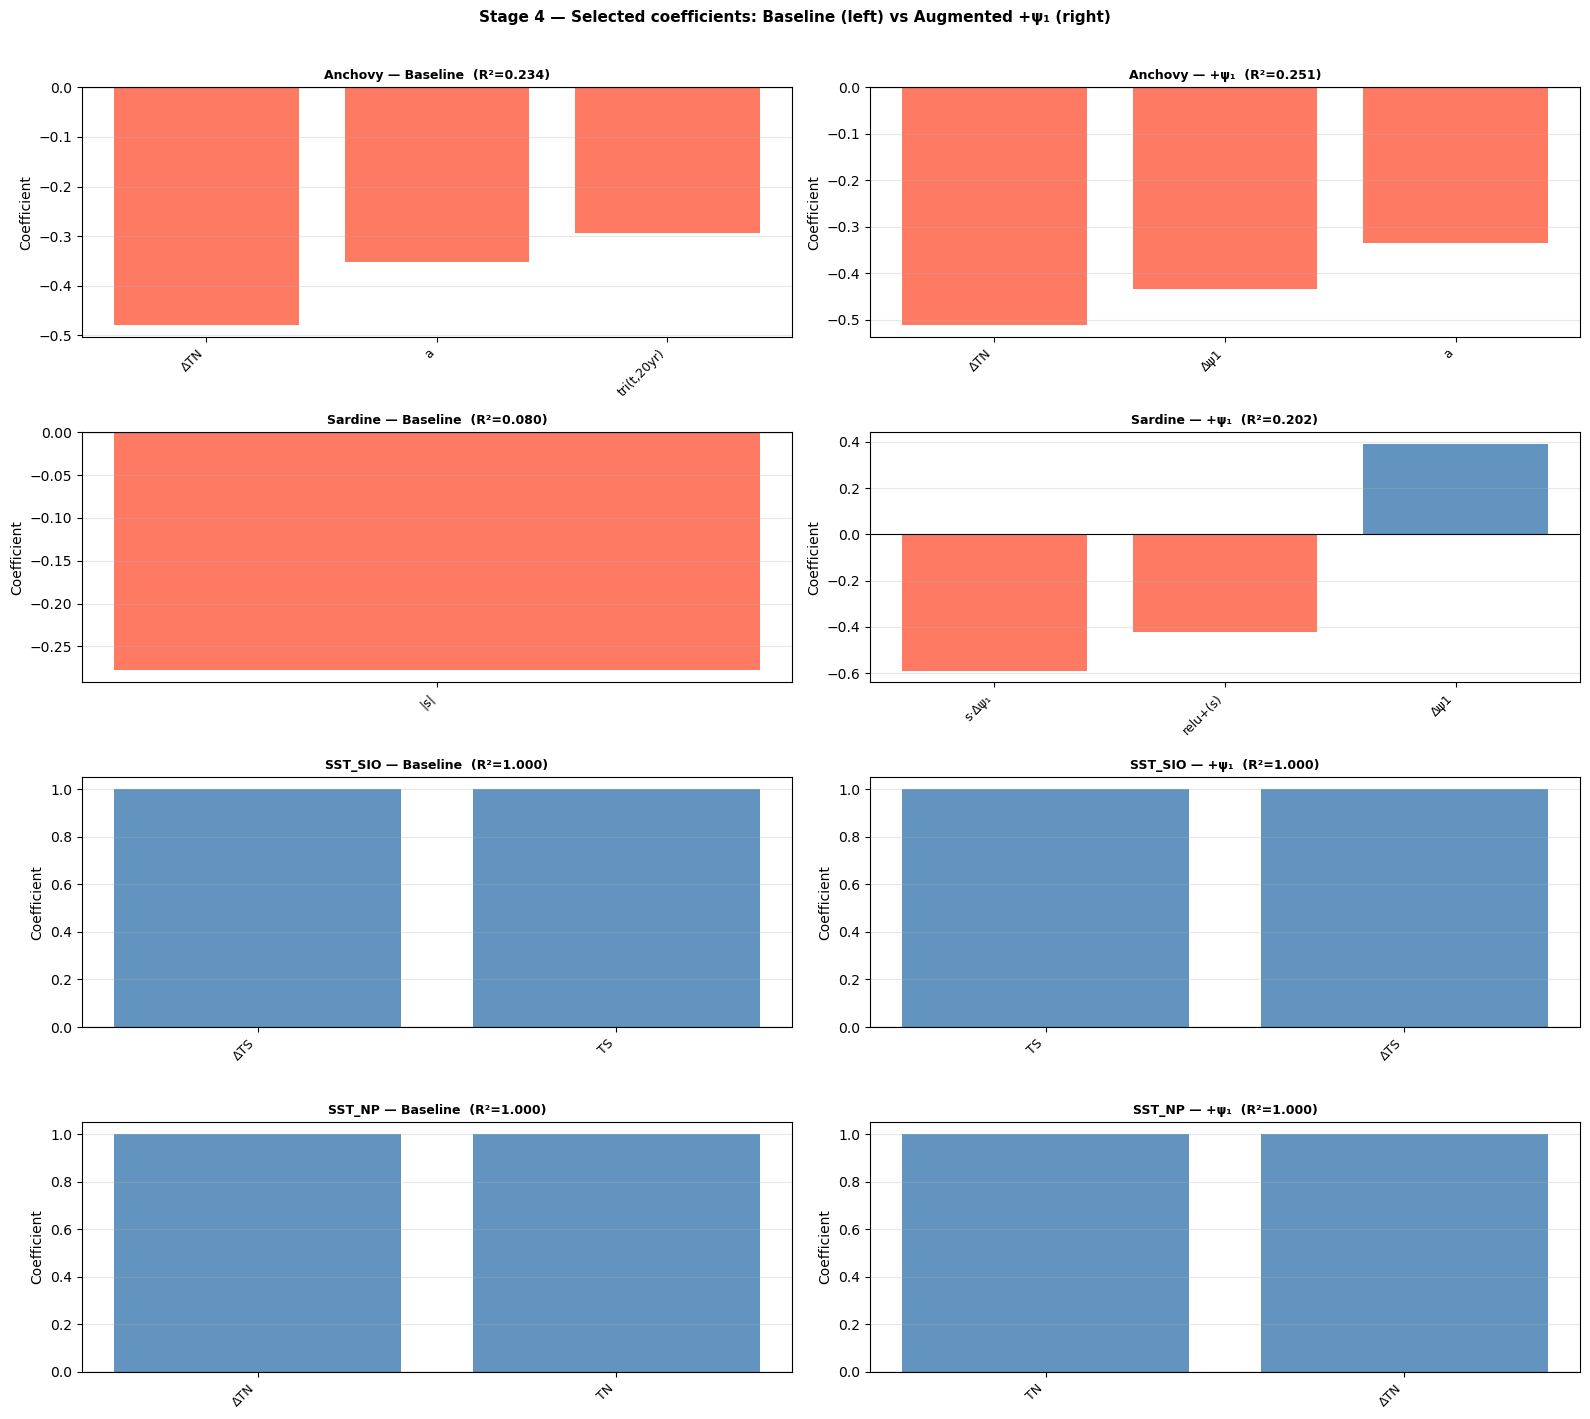

In [156]:
MAX_TERMS    = 3
LAMBDA_GRID  = np.logspace(-2.3, 0.7, 80)

CAUSAL_BASE = {
    'Anchovy' : ['a',  'TN'],
    'Sardine' : ['s',  'TS'],
    'SST_SIO' : ['TS'],
    'SST_NP'  : ['TN'],
}
CAUSAL_AUG = {
    'Anchovy' : ['a',  'TN', 'ψ1'],
    'Sardine' : ['s',  'TS', 'ψ1'],
    'SST_SIO' : ['TS', 'ψ1'],
    'SST_NP'  : ['TN', 'ψ1'],
}

Xtp1_base_s4 = X_base[1:, :4]
Xtp1_aug_s4  = X_aug[1:,  :4]

def run_stage4(X_full, all_cols, causal_preds, Xtp1, label, t_index):
    """Non-smooth SINDy with per-equation AIC λ selection."""
    results = {}
    print(f"\n{'═'*70}")
    print(f"  {label}  (MAX_TERMS={MAX_TERMS}, AIC λ-selection)")
    print(f"{'═'*70}")
    for tname in TARGET_NAMES:
        allowed = causal_preds[tname]
        Theta, feat = build_causal_library(X_full, all_cols, allowed, t_index)
        y = Xtp1[:, col_map[tname]]
        xi, lam_best, aic_curve, k_curve = fit_with_aic_and_cap(Theta, y, LAMBDA_GRID, MAX_TERMS)
        pred = Theta @ xi
        r2v  = r2_score(y, pred)
        k    = int(np.sum(np.abs(xi) > 0))
        terms = [f"{xi[j]:+.4f}·{feat[j]}" for j in range(len(feat)) if abs(xi[j]) > 1e-10]
        print(f"\n  {tname}(t+1) = {' '.join(terms) if terms else '0'}")
        print(f"    λ* = {lam_best:.4f}  |  k = {k}  |  R²(OSA) = {r2v:.3f}")
        results[tname] = dict(Theta=Theta, feat=feat, y=y, xi=xi,
                               pred=pred, r2=r2v, lam_best=lam_best,
                               aic_curve=aic_curve, k_curve=k_curve)
    return results

results_base_s4 = run_stage4(X_base, all_cols_base, CAUSAL_BASE, Xtp1_base_s4,
                               'BASELINE — without ψ₁', t_idx_base)
results_aug_s4  = run_stage4(X_aug,  all_cols_aug,  CAUSAL_AUG,  Xtp1_aug_s4,
                               'AUGMENTED — with ψ', t_idx)

# ── OSA summary ───────────────────────────────────────────────────────────────
print(f"\n{'═'*65}")
print(f"  STAGE 4 — ONE-STEP-AHEAD R² SUMMARY")
print(f"  {'Equation':12s}  {'R²(base)':>10}  {'R²(+ψ₁)':>10}  {'Δ':>8}")
print(f"  {'─'*50}")
for tname in TARGET_NAMES:
    r2b = results_base_s4[tname]['r2']; r2a = results_aug_s4[tname]['r2']
    delta = r2a - r2b
    print(f"  {tname:12s}  {r2b:>10.3f}  {r2a:>10.3f}  {'▲' if delta>=0 else '▼'}{abs(delta):.3f}")

# ── Coefficient bar charts ────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Stage 4 — Selected coefficients: Baseline (left) vs Augmented +ψ₁ (right)',
             fontsize=11, fontweight='bold', y=1.01)
for i, tname in enumerate(TARGET_NAMES):
    for j, (res, lbl) in enumerate([(results_base_s4, 'Baseline'), (results_aug_s4, '+ψ₁')]):
        ax   = axes[i, j]
        xi   = res[tname]['xi']; feat = res[tname]['feat']
        keep = [(xi[k], feat[k]) for k in range(len(feat)) if abs(xi[k]) > 1e-10]
        if not keep:
            ax.set_title(f'{tname} — {lbl}: null model'); ax.axis('off'); continue
        vals, lbs = zip(*sorted(keep, key=lambda x: abs(x[0]), reverse=True))
        xp = np.arange(len(vals))
        ax.bar(xp, vals, color=['steelblue' if v > 0 else 'tomato' for v in vals], alpha=0.85)
        ax.axhline(0, color='k', lw=0.8)
        ax.set_xticks(xp); ax.set_xticklabels(lbs, rotation=45, ha='right', fontsize=9)
        ax.set_title(f'{tname} — {lbl}  (R²={res[tname]["r2"]:.3f})',
                     fontsize=9, fontweight='bold')
        ax.set_ylabel('Coefficient'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

### Stage 4 — Free-Running Simulation

`Δ(climate)` terms need the *next* climate state. During rollout a two-pass scheme
approximates this: a first pass with Δx ≈ 0 gives a preliminary next state, which
feeds the second pass for the proper Δx. Triangle-wave terms are time-indexed and
need no modification. ψ₁ is always exogenous (observed values used at every step).


═══════════════════════════════════════════════════════════════════════════
  STAGE 4 — OSA and Free-Run R²
                  OSA base    FR base     OSA +ψ₁     FR +ψ₁
  ──────────────────────────────────────────────────────────────
  Anchovy            0.234      0.021       0.251      0.045
  Sardine            0.080      0.016       0.202      0.079
  SST_SIO            1.000     -0.126       1.000     -1.135
  SST_NP             1.000     -0.123       1.000     -2.657

  Note: ψ₁ is treated as exogenous during free-run in both versions.


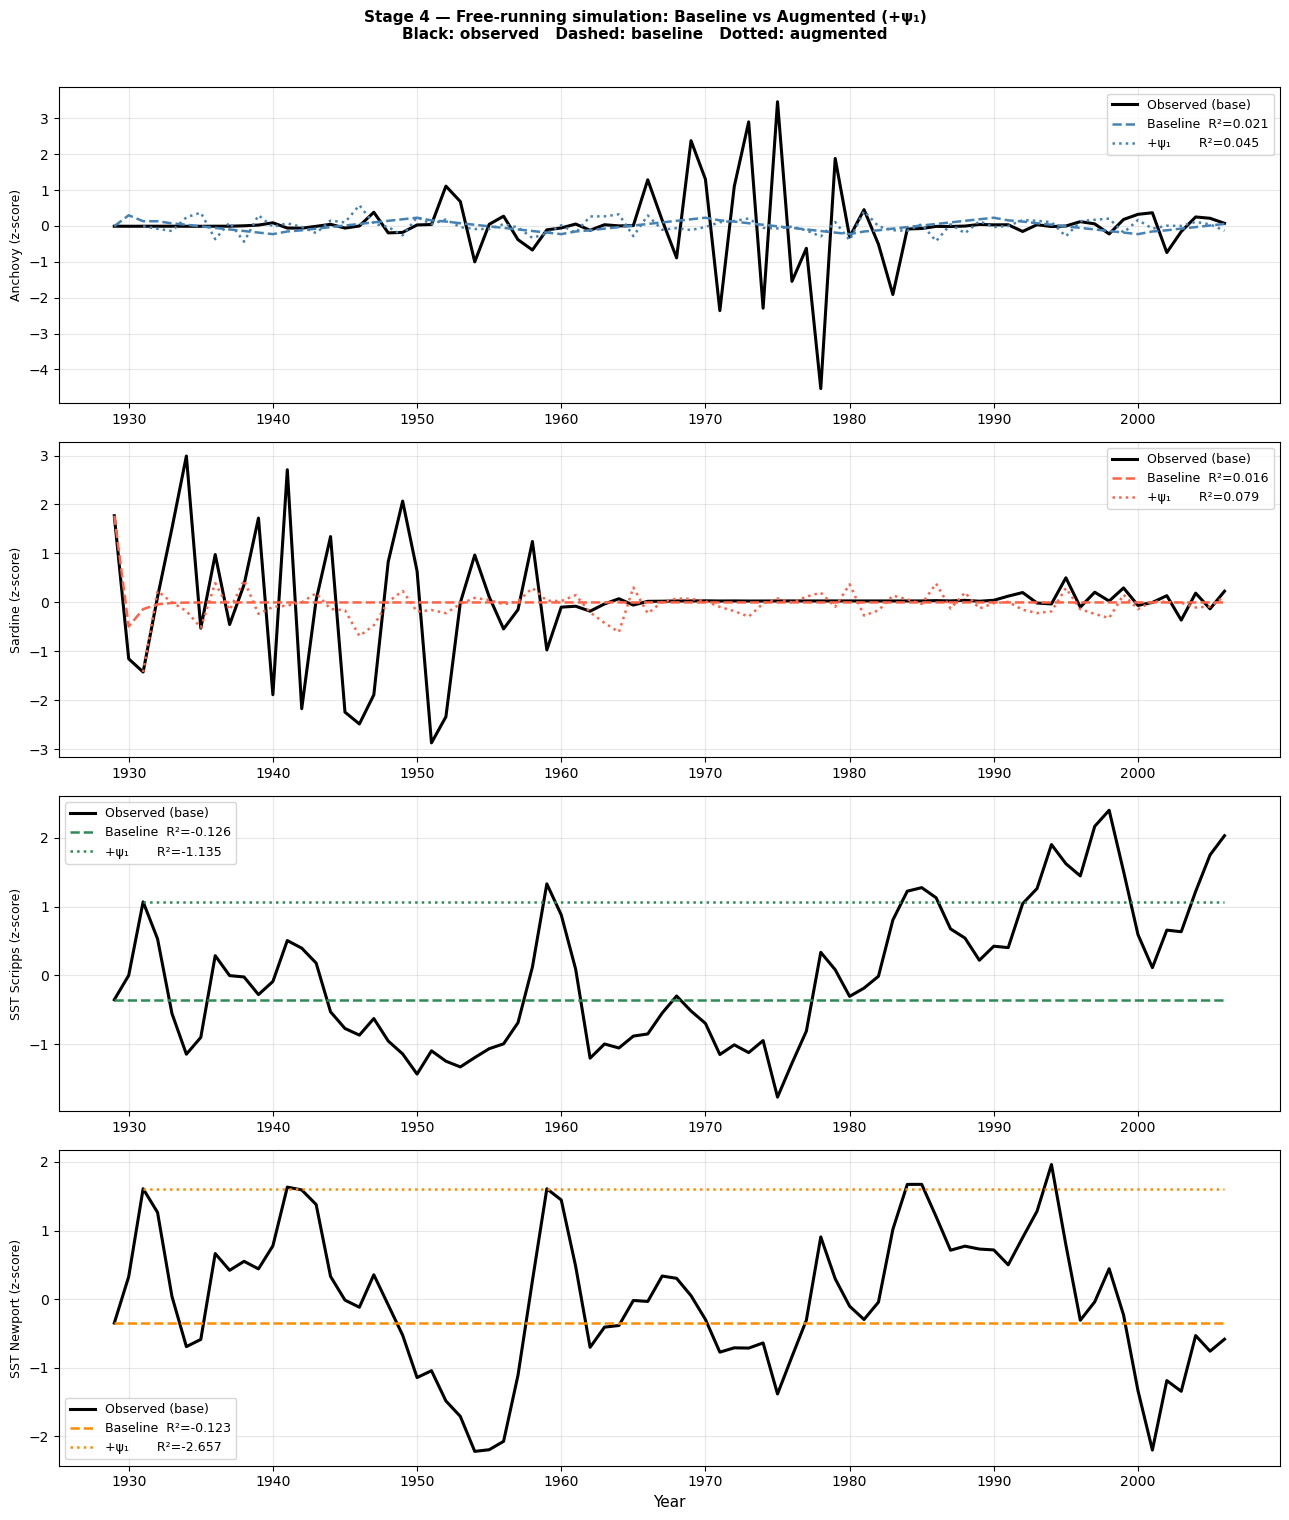

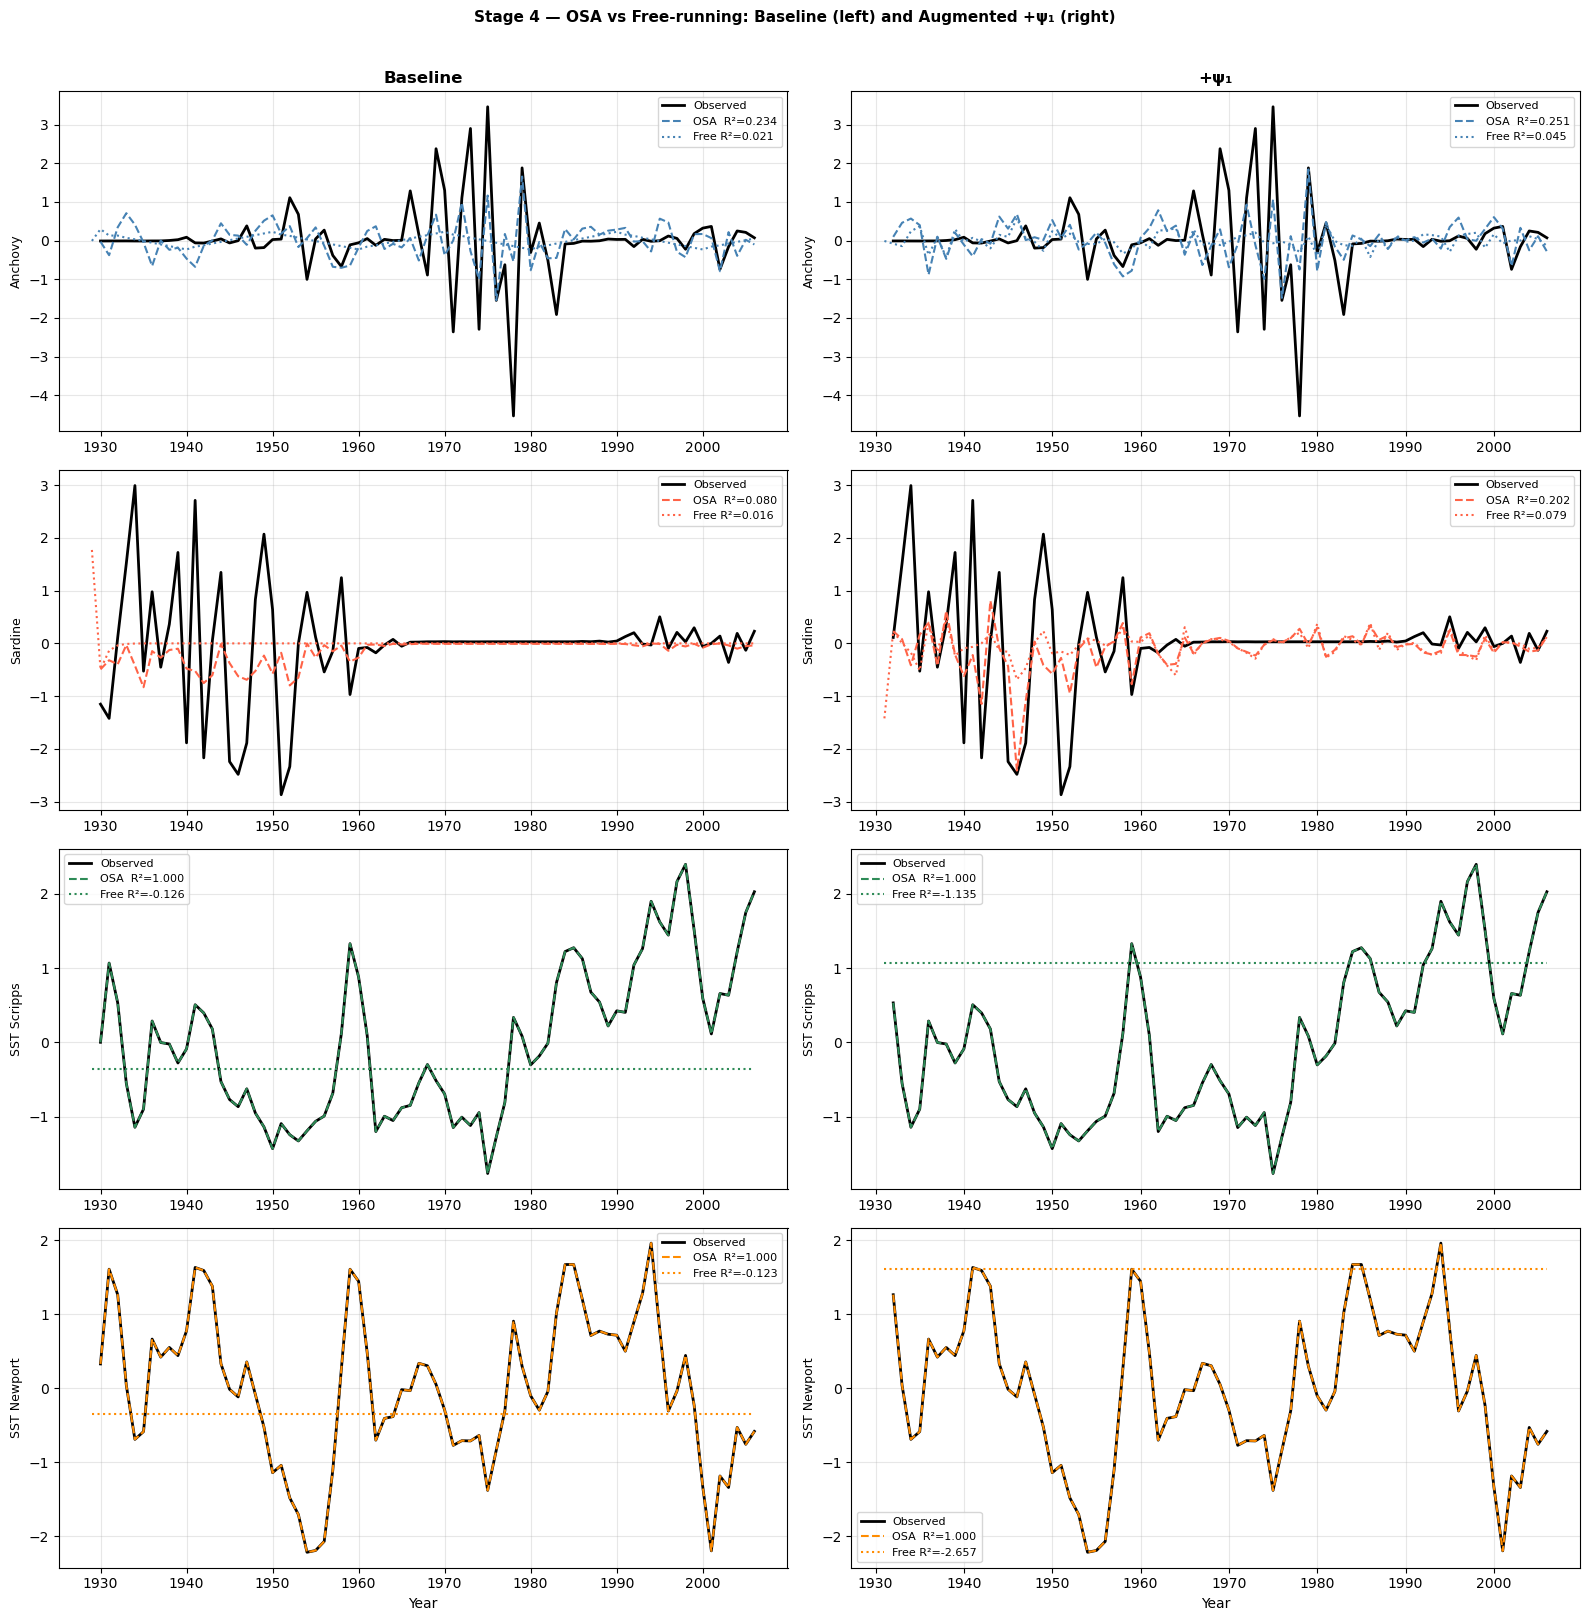

In [157]:
obs_base = X_base[:, :4]          # 78 rows — baseline observed
obs_aug  = X_aug[:,  :4]          # 76 rows — augmented observed
t_yrs_base = years                # full year axis for baseline

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'═'*75}")
print(f"  STAGE 4 — OSA and Free-Run R²")
print(f"  {'':12s}  {'OSA base':>10}  {'FR base':>9}  {'OSA +ψ₁':>10}  {'FR +ψ₁':>9}")
print(f"  {'─'*62}")
for tname in TARGET_NAMES:
    ci = col_map[tname]
    r2b  = results_base_s4[tname]['r2']
    r2a  = results_aug_s4[tname]['r2']
    r2fb = r2_score(obs_base[1:, ci], traj_base_s4[1:, ci])
    r2fa = r2_score(obs_aug[1:,  ci], traj_aug_s4[1:,  ci])
    print(f"  {tname:12s}  {r2b:>10.3f}  {r2fb:>9.3f}  {r2a:>10.3f}  {r2fa:>9.3f}")
print(f"\n  Note: ψ₁ is treated as exogenous during free-run in both versions.")

# ── Trajectory plots (free-run) ───────────────────────────────────────────────
long_names = ['Anchovy', 'Sardine', 'SST Scripps', 'SST Newport']
fig, axes = plt.subplots(4, 1, figsize=(13, 15), sharex=False)
fig.suptitle('Stage 4 — Free-running simulation: Baseline vs Augmented (+ψ₁)\n'
             'Black: observed   Dashed: baseline   Dotted: augmented',
             fontsize=11, fontweight='bold', y=1.01)
for i, (tname, lname) in enumerate(zip(TARGET_NAMES, long_names)):
    ax = axes[i]; ci = col_map[tname]; c = COLORS[i]
    r2b = r2_score(obs_base[1:, ci], traj_base_s4[1:, ci])
    r2a = r2_score(obs_aug[1:,  ci], traj_aug_s4[1:,  ci])
    ax.plot(t_yrs_base, obs_base[:, ci],     color='k', lw=2.2, label='Observed (base)')
    ax.plot(t_yrs_base, traj_base_s4[:, ci], color=c,   lw=1.8, ls='--', label=f'Baseline  R²={r2b:.3f}')
    ax.plot(t_yrs,      traj_aug_s4[:, ci],  color=c,   lw=1.8, ls=':',  label=f'+ψ₁       R²={r2a:.3f}')
    ax.set_ylabel(f'{lname} (z-score)', fontsize=9)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[-1].set_xlabel('Year', fontsize=11)
plt.tight_layout(); plt.show()

# ── Side-by-side OSA vs free-run (4×2 grid) ──────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(16, 16), sharex=False)
fig.suptitle('Stage 4 — OSA vs Free-running: Baseline (left) and Augmented +ψ₁ (right)',
             fontsize=11, fontweight='bold', y=1.01)
for i, (tname, lname) in enumerate(zip(TARGET_NAMES, long_names)):
    ci = col_map[tname]; c = COLORS[i]
    for j, (res, traj_fr, obs, t_full, t_osa, lbl) in enumerate([
        (results_base_s4, traj_base_s4, obs_base, t_yrs_base, years[1:],  'Baseline'),
        (results_aug_s4,  traj_aug_s4,  obs_aug,  t_yrs,      t_yrs[1:], '+ψ₁'),
    ]):
        ax = axes[i, j]
        r2_os = res[tname]['r2']
        r2_fr = r2_score(obs[1:, ci], traj_fr[1:, ci])
        ax.plot(t_osa,  obs[1:, ci],       color='k', lw=2.0, label='Observed')
        ax.plot(t_osa,  res[tname]['pred'], color=c,   lw=1.5, ls='--', label=f'OSA  R²={r2_os:.3f}')
        ax.plot(t_full, traj_fr[:, ci],     color=c,   lw=1.5, ls=':',  label=f'Free R²={r2_fr:.3f}')
        ax.set_ylabel(lname, fontsize=9)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
        if i == 0: ax.set_title(lbl, fontweight='bold')
axes[-1, 0].set_xlabel('Year'); axes[-1, 1].set_xlabel('Year')
plt.tight_layout(); plt.show()
